<p align="center">
  <img src="https://github.com/deel-ai/xplique/blob/master/docs/assets/banner.png?raw=true"/>
</p>

---

**GradCAM**: 📘 <a href="https://deel-ai.github.io/xplique/api/attributions/grad_cam/"> Documentation</a>  |  <img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> <a href="https://github.com/deel-ai/xplique/blob/master/xplique/attributions/grad_cam.py"> Source</a>  | 📰 <a href="https://arxiv.org/abs/1610.02391"> Original Paper</a>

**GradCAMPP**: 📘 <a href="https://deel-ai.github.io/xplique/api/attributions/grad_cam_pp/"> Documentation</a>  |  <img src="https://github.githubassets.com/images/icons/emoji/octocat.png" width=20> <a href="https://github.com/deel-ai/xplique/blob/master/xplique/attributions/grad_cam_pp.py"> Source</a>  | 📰 <a href="https://arxiv.org/abs/1710.11063"> Original Paper</a>

🦊 <a href="https://github.com/deel-ai/xplique/blob/master/TUTORIALS.md"> More Xplique tutorials</a>

---

_Author: Antonin Poché_

---

# Welcome to the **GradCAM and GradCAMPP attribution** tutorial

In this tutorial, we will present the methods and few tips to use the right parameters. We also answer to frequently asked questions and dig into the details of the parameters through examples.

Those two methods have exactly the same parameters which are used in the same way, this leads to similar behaviors. Therefore we group all this methods in a unique tutorial. Nevertheless, we will highlight the difference between each methods.

💡 The Grad-CAM and Grad-CAM++ attribution methods were integrated into the Xplique framework and we propose here to have an overview of the possibilities you have to play with those methods to explain the outputs of your model.

---

# **Table of content:**

- [The methods](#intro)

- [Parameters overview](#overview)

- [Parameters tuning tips](#tips)

- [Frequently asked questions](#faq)

- [Utilization and parameters impact examples](#examples)

    - [Set-up](#setup)

    - [Methods simple utilization](simple)

    - [Parameters influence](#influence)

# <a name="intro"> The methods

### **Attribution methods**

The main objective in attributions techniques is to highlight the discriminating variables for decision-making. For instance, with Computer Vision (CV) tasks, the main goal is to underline the pixels contributing the most in the input image(s) leading to the model’s output(s).



### **Back-propagation attribution methods**

Back-propagation methods are one of the two groups of attribution methods with perturbation based methods. Those methods use the weights of the model to back-propagate the importance from the prediction (class activation or regression) to the inputs. It was first introduced in 2013, with the saliency method from <a href="https://arxiv.org/abs/1312.6034">Simonyan et al</a>.  Back-propagation methods can be seen as white-box methods as they need the weights of the model.

### **CAM**

Class Activation Map (CAM) (<a href="https://arxiv.org/abs/1512.04150">Zhou et al. 2015</a>) was the main inspiration for Grad-CAM as Grad-CAM generalize CAM and Grad-CAM++ further extend it.

CAM can be applied to networks like VGG where there are block of convolutionnal layers before a dense layer and the output. The method computes attributions on the last convolutionnal layer, a value is given to each of its spatial coordinates. It uses the fact that convolutionnal layers and thus convolutionnal features mapping conserves a notion of spaciality between the input and the output. As such, after obtaining attributions for the last convolutionnal layer, they upsample the attributions to match the size of the input and obtain features attributions.

Before jumping to the formula, we need to introduce the Global Average Pooling (GAP) function. It basically sums an output on the spatial dimensions, living one value for each channel.

*(In this method and the two following, approximately all elements depends on the input $x$, thus it will be remove from the notations to increase readability.)*

Let's call the feature activation of the last convolutionnal layer $A$, such that $A_{ij}^k$ corresponds to the $(i,j)$ value on channel $k$.

$$GAP(A^k) = \sum_i \sum_j A_{ij}^k$$

Now, on the computation of the convolutionnal layer attributions can be defined through the following formula, where $CAM_c$ are the convolutionnal attributions for input $x$ and class $c$. The GAP are weighted by $w_c^k$ the weight between the channel $k$ and the output corresponding to class $c$.

$$ CAM_c = \sum_k w_c^k GAP(A^k) $$

Therefore, explanation function $\phi_c$ of a class $c$, can be defined by:

$$\phi_c(x) = upsample_{size(x)}(CAM_c) $$

   


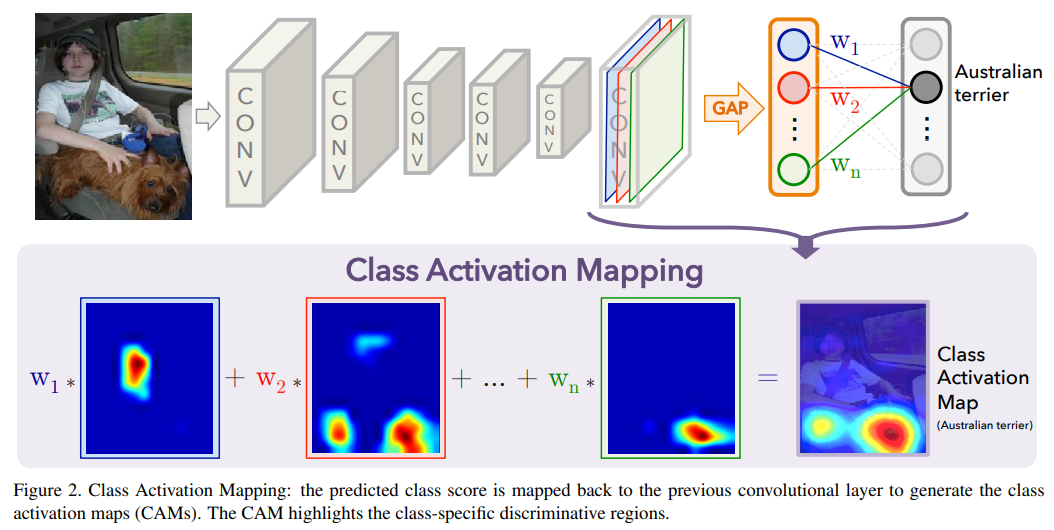

### **Grad-CAM**

<a href="https://arxiv.org/abs/1610.02391">Ramprasaath et al.</a> described Grad-CAM as "*Grad-CAM uses the gradient information flowing into the
last convolutional layer of the CNN to assign importance
values to each neuron for a particular decision of interest.*"

The method is really close to CAM, they also assign attribution to the last convolutionnal layer and upsample them to the input size. They also use the GAP function. Nevertheless, their design allow the use of the method on each convolutionnal layer and the last layer do not need to necessarly be a dense layer.

The difference with the CAM method is there use of the gradient computed via back-propagation $g_{ij}^{kc} = \frac{\delta S_c}{\delta A_{ij}^k}$. Where $S_c$ the unormalized score (layer before softmax) for class $c$ and $A_{ij}^k$ the activation of the studied convolutionnal layer output at channel $k$ and coodinates $(i,j)$.

They define the coefficient $\alpha_k^c$ by taking the GAP of this gradient. Z represent the number of elements in a channel of the studied convolutionnal layer.

$$\alpha_c^k = \frac{1}{Z} \sum_i \sum_j g_{ij}^{kc}$$

Now, on the computation of the convolutionnal layer attributions can be defined through the following formula, where $GradCAM_c$ are the convolutionnal attributions for class $c$. The GAP are weighted by $A^k$ the activations of channel $k$. $ReLU$ is the rectified linear unit function.

$$ GradCAM_c = ReLU(\sum_k \alpha_c^k A^k)$$

Therefore, explanation function $\phi_c$ of a class $c$, can be defined by:

$$\phi_c(x) = upsample_{size(x)}(GradCAM_c) $$

### **Grad-CAM++**

In their paper, <a href="https://arxiv.org/abs/1710.11063">Chattopadhyay, Sarkar et al.</a> argue that Grad-CAM is biased toward bigger object in the image. Therefore, they propose Grad-CAM++ to solve this problem.

The two final step are similar, the difference is in their definition of $\alpha_k^c$. They take the $ReLU$ value of the gradient and introduce a coefficient $\alpha_{ij}^{kc}$ to remove the aforementioned bias.

$$\alpha_c^k = \frac{1}{Z} \sum_i \sum_j \alpha_{ij}^{kc} ReLU(g_{ij}^{kc})$$

They define $\alpha_{ij}^{kc}$ as:

$$\alpha_{ij}^{kc} = \frac{(g_{ij}^{kc})^2}{2(g_{ij}^{kc})^2 + \sum_a \sum_b A_{ab}^k (g_{ij}^{kc})^3}$$


# <a name="overview">Parameters overview </a>

As most methods of the Xplique library, an explanation method have a few number of attributes (and their default values) useful to increase your explanation quality.

```python
explainer = GradCAM(model,
                    output_layer: Union[str, int] = None,
                    batch_size: int = 32,
                    conv_layer: Union[str, int] = None)
```

- The `output_layer` parameter is the index or name of the output layer corresponding to the label layer. The last layer layers can be activated (linear, softmax ...). The value of `output_layer` has no impact on the simulation time.

- The `batch_size` define the number of inputs to treat simultaneously.

- The `conv_layer` parameter is the index or name of the convolutionnal layer on which the algorithm is applied. The value of `conv_layer` has no impact on the simulation time.

The choice of the `conv_layer` and the `output_layer` have a great deal towards our explainer performance. The `conv_layer` layer has to be before the `output_layer` layer in the neural network system.

The detail on each attribute influence will be provided in the [Parameters influence](#influence) section.

# <a name="tips">Parameters tuning tips</a>

- The `output_layer` represents the index or name of the layer from which begin the back-propagation. It should be left to None, i.e the last layer of the model or the class activation layer.
- The `batch_size` represents the number of perturbed images treated simultaneously. It has an impact on the memory usage. You may use the batch size from your model training.
- The `conv_layer` parameter represents the index or the name of the convolutionnal layer the algorithm is applied on. It should be left to `None` to select the last convolutionnal layer in most cases.

# <a name="faq">Frequently asked questions</a>

### **Out of memory error**

You asked too much memory from your RAM. This is usually cause by treating too much samples simultaneously, thus reducing the `batch_size` should resolve your problem. Otherwise you may check if there is nothing else runing on your machine.

### **Which method is the best**

None, you should try them and compare them, there will always be a case for one method to shine. To compare them you should use the metrics and your own intuition. To learn how to use the metrics, compare the methods and interpret them, please refer to the <a href="https://deel-ai.github.io/xplique/tutorials/"> other Xplique tutorials</a>.

However, Grad-CAM++ is supposed to be an unbiased version of Grad-CAM. Hence, it is supposely, a better method.

### **The computation time is too long**

For each sample you want an explanation on, the gradient is computed via backpropagation. It should not be long, however if you want to reduce this time, you have two possibilities:
- Increase the `batch_size`, you machine will thus do bigger computations simultaneously. However it may lead to out of memory errors.
- Or, you can choice to reduce the number of samples (images, timeseries) you want an explanation on. (Maybe wrongly classified samples are more interesting to analyze or if you evaluate your method through metrics, only a part of the test set could be sufficient).

### **The explanation is too smooth**

This is one of the drawback of the methods, depending on the architecture of your model, the size of the last convolutionnal layer output may be too small. Therefore the computed activations will be made on a small matrix and after upsampling, it will seem too smooth.

### **The explanation does not make sense**

With GradCAM and GradCAMPP, if your explanation does not make sense or is inexistant, there are four possibilities :
- The parameters have been modified and values are not adapted. You should set the layers parameters (`output_layer` and `conv_layer`) back to their default value (`None`).
- The `targets` parameter of the `explain` method may have not adapted values. It should take values in $\{-1, 0, 1\}$, we often use the model prediction (one hot encoding after argmax) or the dataset labels. For regression, it should be only ones. Verify that your `targets` parameter values are in $\{-1, 0, 1\}$.
- If the model do not work well, it is natural that explaining its behavior will not be understandable. You can come to this conclusion if other explainability methods do not work well either. In this case, you may want to modify your model.
- The method you use may not be adapted to the model or the dataset. You will see it quickly if other explanability methods work well. In this case, you should just use the other methods.

# <a name="examples">Utilization and parameters impact examples</a>

This section will present the different parameters and their influence in details. It will be done through examples, therefore, a little set up part to load a model and an image is necessary. Then a simple utilization is provided, before an overview of the different parameters and their detail.

## <a name="sec">Set-up</a>

We start by importing Xplique and some other necessary libraries.

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import tensorflow as tf
from math import ceil
from time import time

import xplique
from xplique.attributions import GradCAM, GradCAMPP
from xplique.plots import plot_attributions
from tensorflow.keras.models import load_model

Now we will load an image and a well-known model [Inception V3](https://keras.io/api/applications/inceptionv3/).

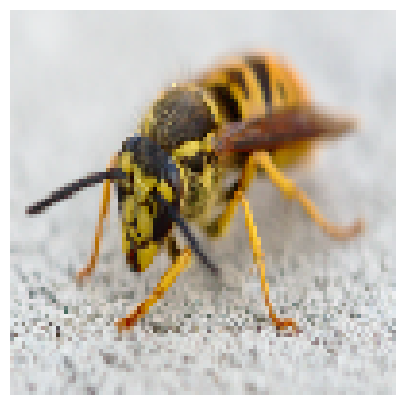

In [18]:
# load, prepare and show the sample
image = "Wasp(2).png"

x = np.expand_dims(tf.keras.preprocessing.image.load_img(image, target_size=(100, 100)), 0)
x = np.array(x, dtype=np.float32) / 255.0

y = np.expand_dims(tf.keras.utils.to_categorical(10, 12), 0)

plt.rcParams["figure.figsize"] = [12.5, 5]
plt.imshow(x[0])
plt.axis('off')
plt.show()

In [12]:
model_path = r"C:\Users\USER\Documents\GitHub\2023-24c-fai1-adsai-MarioVelichkov230623\Deliverables\model_augmented.h5"
model = load_model(model_path)
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 49, 49, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 10, 10, 128)     

## <a name="simple">Methods simple utilization</a>

This a minimal example on how to apply the SmoothGrad, SquareGrad and VarGrad methods. This focus on the right specification of the methods parameters. For further details and explanations on the attribution explainers API, please refer to the [Feature attribution tutorial](https://colab.research.google.com/drive/1XproaVxXjO9nrBSyyy7BuKJ1vy21iHs2)

GradCAM


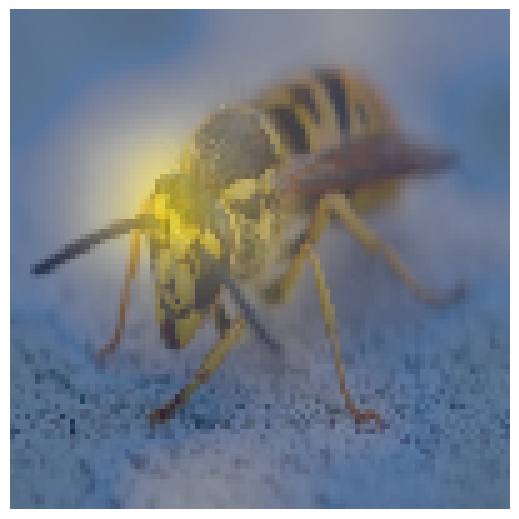

GradCAMPP


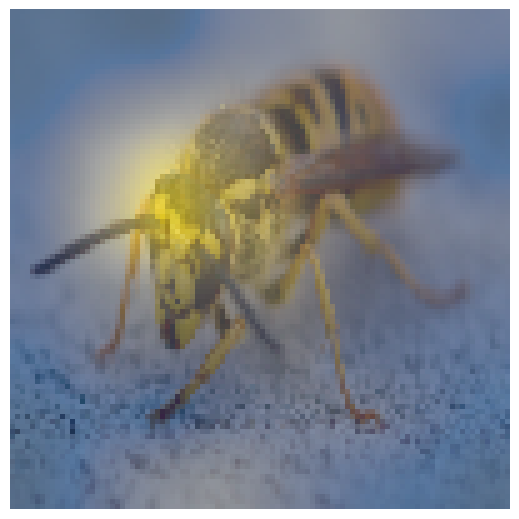

In [19]:
# define arbitrary parameters (common for all methods)

parameters = {
    "model": model,
    "output_layer": -1,
    "batch_size": 16,
    "conv_layer": None,
}

# instanciate one explainer for each method
explainers = {
    "GradCAM": GradCAM(**parameters),
    "GradCAMPP": GradCAMPP(**parameters),
}

# iterate on all methods
for method_name, explainer in explainers.items():
    # compute explanation by calling the explainer
    explanation = explainer.explain(x, y)

    # visualize explanation with plot_explanation() function
    print(method_name)
    plot_attributions(explanation, x, img_size=5, cmap='cividis', cols=1, alpha=0.6)
    plt.show()

The GradCAM and GradCAMPP methods need some knowledge to set their parameters right. Therefore we propose to summarize those informations in [the parameters tuning tips part](#tips). The parameters are described and explained in the following sections.

## <a name="influence">Parameters influence</a>

This section will present the influence of each parameter, it will be accompanied by visualization to illustrate it. Each parameter will be described one by one.

The two presented methods are grouped together because they have the same parameters and those parameters have similar influences. Therefore we will import one of the two methods as "Method" and make the analysis with it. However, you can change the studied method by commenting and uncommenting the corresponding lines.

### **output_layer**

The `output_layer` parameter is an integer indexing the layer from which begin the back-propagations or a string with the name of this layer. The different papers consider the last layer of the neural neural which is the class activation layer. (The methods can also be applied to regression methods, please see the corresponding tutorial from the <a href="https://deel-ai.github.io/xplique/tutorials/"> list of Xplique tutorials</a>).

To come back to the `output_layer` parameter, we suggest not to change it as the resulting attributions would not be easily interpretable and may be misleading.

### **batch_size**

The `batch_size` parameter should be a positive integer, it indicates the number of perturbed images treated simultaneously.
- Too small values will increase the execution time.
- Too huge values may lead to out of memory errors.
This parameter should be set taking into account your hardware and the image size. The most simple solution is to used the same batch size you use during the training of your model.

### **conv_layer**

The `conv_layer` parameter corresponds to the index or name of the convolutionnal layer the attributions are computed on.

There may be a huge number of convolutionnal layers in your model, for most of them, the explanation will not make sense. Furthermore, there is a low chance that the explanation will be more pertinent than the one obtained by default on the last convolutionnal layer.

Therefore, in most cases, the `conv_layer` parameter should be left to `None`.

In [21]:
# This shows the architecture of the model
# We can see that the last convolutionnal layer is "conv2d_93"
print(model.summary())

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 98, 98, 32)        896       
                                                                 
 max_pooling2d_7 (MaxPooling  (None, 49, 49, 32)       0         
 2D)                                                             
                                                                 
 conv2d_8 (Conv2D)           (None, 47, 47, 64)        18496     
                                                                 
 max_pooling2d_8 (MaxPooling  (None, 23, 23, 64)       0         
 2D)                                                             
                                                                 
 conv2d_9 (Conv2D)           (None, 21, 21, 128)       73856     
                                                                 
 max_pooling2d_9 (MaxPooling  (None, 10, 10, 128)     

conv_layer: None -> 0.0845s


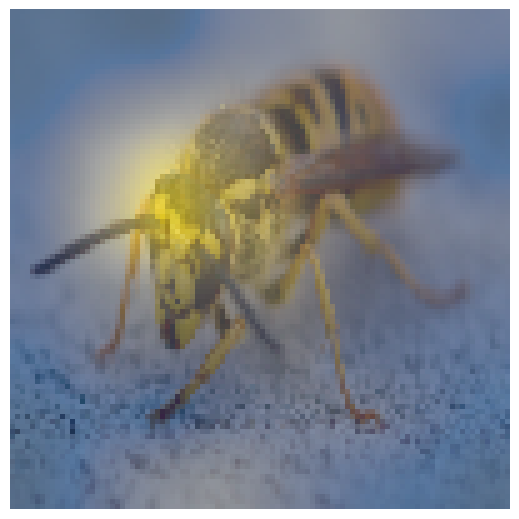

conv_layer: conv2d_7 -> 0.1142s


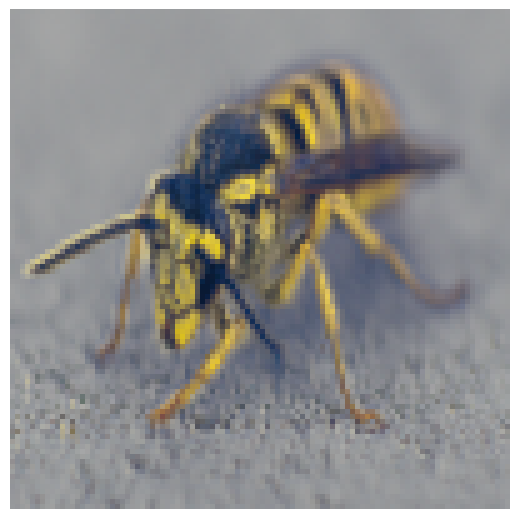

conv_layer: conv2d_8 -> 0.1072s


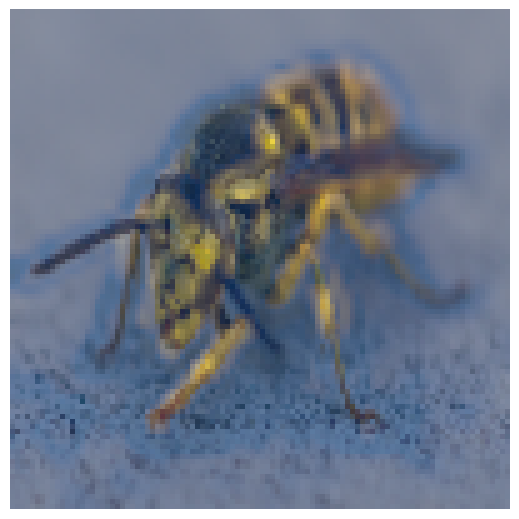

conv_layer: conv2d_9 -> 0.0764s


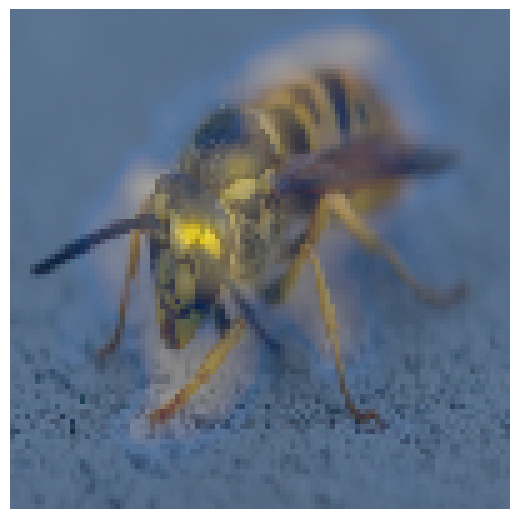

conv_layer: conv2d_10 -> 0.0765s


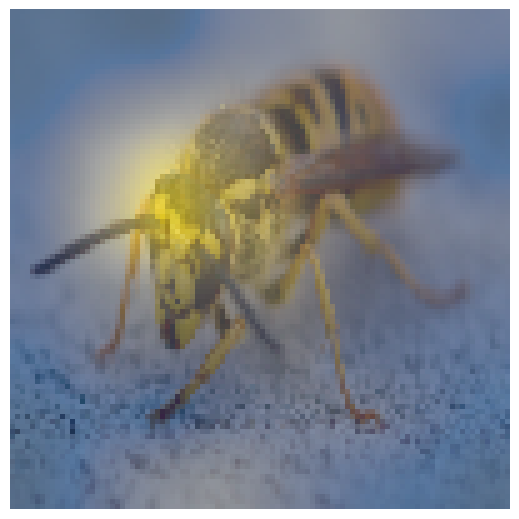

In [23]:
# Method = GradCAM
Method = GradCAMPP

batch_size = 16
# None will select "conv2d_93" (cf architecture)
# Most other values will make warnings or errors
conv_layers = [None, 'conv2d_7', 'conv2d_8', 'conv2d_9', 'conv2d_10']

for conv_layer in conv_layers:
    t = time()
    explainer = Method(model,
                       batch_size=batch_size,
                       conv_layer=conv_layer)

    explanation = explainer.explain(x, y)
    print(f"conv_layer: {conv_layer} -> {round(time()-t, 4)}s")

    plot_attributions(explanation, x, img_size=5, cmap='cividis', alpha=0.6)
    plt.show()